# Steam 신작 시장 진입 전략 분석

## 장르·태그별 기회와 경쟁 리스크

본 노트북의 목적은 비교적 소규모의 인디 게임 개발사가 Steam(PC 게임 유통 플랫폼)에 출시할 신규 게임을 계획하는 단계에서, 어떤 장르(게임의 큰 분류) 또는 태그(게임의 세부 특징을 나타내는 키워드) 시장에 진입하는 것이 상대적으로 유리한지 판단하는 것입니다.

주요 용어는 다음과 같습니다.

- Steam: PC 게임을 판매하고 이용자가 구매·평가할 수 있는 대표적인 온라인 플랫폼입니다.
- 장르: Action, Strategy, Simulation처럼 게임의 큰 유형을 나타내는 분류입니다.
- 태그: Horror, Roguelike, Pixel Graphics처럼 게임의 분위기, 방식, 소재 등을 더 세부적으로 나타내는 키워드입니다.
- owners: Steam 데이터에서 제공되는 보유자 수 추정 범위이며, 실제 판매량이 아니라 해당 게임을 보유한 이용자 수의 추정치입니다.
- 리뷰 수: 이용자가 남긴 긍정 리뷰와 부정 리뷰의 합계이며, 본 분석에서는 시장 관심도의 대리 지표로 사용합니다.
- proxy: 직접 관측하기 어려운 값을 대신 판단하기 위해 사용하는 대리 지표입니다.

분석은 다음의 기준에 따라 단계적으로 구성됩니다.

1. Steam 시장의 장르별 공급량 차이 확인
2. 공급량과 시장 매력도 간 관계 검토
3. 총수요와 게임당 수요의 차이 분석
4. 장르별 승자독식 구조(상위 소수 게임에 성과가 집중되는 구조)와 신규 진입 리스크 검토
5. 인디 게임(대형 퍼블리셔보다 상대적으로 작은 규모의 개발팀이 만든 게임)의 상위권 진입 사례 확인
6. 장르·태그별 기회 시장 도출

주의: 본 데이터는 실제 매출 또는 정확한 판매량이 아니라 Steam 공개 지표와 owners 추정치(보유자 수 추정 범위)를 포함합니다.  
따라서 모든 결론은 의사결정 보조 지표로 해석해야 합니다.


In [1]:
# 기본 라이브러리 및 시각화 설정
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore")


def set_korean_font():
    # Windows 환경의 한글 표시용 Malgun Gothic 우선 적용
    candidates = ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "AppleGothic"]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.family"] = font
            return font
    return "DejaVu Sans"


KOREAN_FONT = set_korean_font()
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "font.family": KOREAN_FONT,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "figure.dpi": 120,
    },
)


def finish_plot(fig=None, right_margin=1.0):
    # 그래프 요소 겹침 방지를 위한 여백 정리
    if fig is None:
        fig = plt.gcf()
    fig.tight_layout(rect=[0, 0, right_margin, 1])
    plt.show()


def annotate_points(ax, data, label_col, x_col, y_col, n=8):
    # 산점도 가독성 확보를 위한 주요 점 라벨 표시
    for _, row in data.head(n).iterrows():
        ax.text(row[x_col], row[y_col], str(row[label_col]), fontsize=8, alpha=0.85)


print("사용 폰트:", KOREAN_FONT)


사용 폰트: Malgun Gothic


## 1. 데이터 로딩

`games.csv`는 Steam 게임의 기본 정보, 가격, 리뷰 수(긍정 리뷰와 부정 리뷰의 합계), owners 추정치(게임 보유자 수 추정 범위), 장르(큰 게임 분류), 태그(세부 특징 키워드)를 포함합니다.  


In [2]:
DATA_PATH = Path("games.csv")

COLUMNS = [
    "AppID", "Name", "Release date", "Estimated owners", "Peak CCU", "Required age",
    "Price", "Discount", "DLC count", "About the game", "Supported languages",
    "Full audio languages", "Reviews", "Header image", "Website", "Support url",
    "Support email", "Windows", "Mac", "Linux", "Metacritic score", "Metacritic url",
    "User score", "Positive", "Negative", "Score rank", "Achievements",
    "Recommendations", "Notes", "Average playtime forever",
    "Average playtime two weeks", "Median playtime forever",
    "Median playtime two weeks", "Developers", "Publishers", "Categories",
    "Genres", "Tags", "Screenshots", "Movies"
]

raw = pd.read_csv(DATA_PATH, header=0, names=COLUMNS, low_memory=False)
print("원본 데이터 크기:", raw.shape)
raw[["AppID", "Name", "Price", "Estimated owners", "Positive", "Negative", "Genres", "Tags"]].head(3)


원본 데이터 크기: (122611, 40)


,AppID,Name,Price,Estimated owners,Positive,Negative,Genres,Tags
0,2539430,Black Dragon Mage Playtest,0.00,0 - 0,0,0,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,5.24,0 - 20000,252,3,Adventure,"Adventure,Visual Novel,Anime,Cute"
2,1034400,Mystery Solitaire The Black Raven,4.99,0 - 20000,21,3,Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."


## 2. 전처리와 시장 단위 정의

본 분석에서 중요한 단위는 개별 게임이 아니라 **장르·태그**입니다.  
Steam의 장르(큰 게임 분류)와 태그(세부 특징 키워드)는 한 게임에 여러 개가 부여될 수 있으므로, 아래 분석의 장르·태그별 게임 수는 중복 집계됩니다.

리뷰 기반 성과 분석에는 `Positive + Negative >= 25`인 게임만 사용합니다.  
여기서 `Positive`는 긍정 리뷰 수, `Negative`는 부정 리뷰 수를 의미합니다.  

리뷰 수가 지나치게 적으면 산출되는 통계값에 유의성이 떨어질 수 있기 때문에 배제하였습니다.  
다만 공급량 분석에서는 시장에 등록된 게임 수가 중요하므로 전체 게임을 함께 사용합니다.


In [3]:
def parse_owners(value):
    nums = [int(x) for x in re.findall(r"\d+", str(value).replace(",", ""))]
    if len(nums) >= 2:
        return nums[0], nums[1], (nums[0] + nums[1]) / 2
    return 0, 0, 0


def split_list_text(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    text = str(value).strip()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    return [x.strip() for x in re.split(r",|;", text) if x.strip()]


def count_languages(value):
    if pd.isna(value) or str(value).strip() == "":
        return 0
    text = re.sub(r"<.*?>", "", str(value))
    return len([x for x in re.split(r",|;", text) if x.strip()])


df = raw.copy()

numeric_cols = [
    "Price", "Discount", "DLC count", "Peak CCU", "Positive", "Negative",
    "Achievements", "Average playtime forever", "Median playtime forever"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

owners = df["Estimated owners"].apply(parse_owners).apply(pd.Series)
owners.columns = ["owners_min", "owners_max", "owners_mid"]
df = pd.concat([df, owners], axis=1)

df["total_reviews"] = df["Positive"] + df["Negative"]
df["estimated_realized_price"] = df["Price"] * (1 - df["Discount"].clip(0, 100) / 100)
df["revenue_proxy"] = df["owners_mid"] * df["estimated_realized_price"]
df["positive_ratio"] = np.where(df["total_reviews"] > 0, df["Positive"] / df["total_reviews"], np.nan)
df["release_date"] = pd.to_datetime(df["Release date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["language_count"] = df["Supported languages"].apply(count_languages)
df["genre_list"] = df["Genres"].apply(split_list_text)
df["tag_list"] = df["Tags"].apply(split_list_text)

# 인디 여부: 원본 정답 컬럼이 아닌 장르/태그 텍스트 기반 분석용 정의
df["is_indie"] = df["genre_list"].apply(lambda xs: "Indie" in xs) | df["tag_list"].apply(lambda xs: "Indie" in xs)

# 상업 규모 proxy: 실제 매출 부재에 따른 owners 추정치와 할인 반영 가격의 결합

analysis_df = df[df["total_reviews"] >= 25].copy()
analysis_df["log_total_reviews"] = np.log1p(analysis_df["total_reviews"])
analysis_df["log_owners_mid"] = np.log1p(analysis_df["owners_mid"])

all_genre_long = df.explode("genre_list").rename(columns={"genre_list": "market"})
all_genre_long = all_genre_long[all_genre_long["market"].notna() & (all_genre_long["market"] != "")]
genre_long = analysis_df.explode("genre_list").rename(columns={"genre_list": "market"})
genre_long = genre_long[genre_long["market"].notna() & (genre_long["market"] != "")]

all_tag_long = df.explode("tag_list").rename(columns={"tag_list": "market"})
all_tag_long = all_tag_long[all_tag_long["market"].notna() & (all_tag_long["market"] != "")]
tag_long = analysis_df.explode("tag_list").rename(columns={"tag_list": "market"})
tag_long = tag_long[tag_long["market"].notna() & (tag_long["market"] != "")]

data_audit = pd.DataFrame({
    "항목": [
        "전체 게임 수",
        "리뷰 25개 이상 분석 대상",
        "장르가 있는 전체 게임-장르 행",
        "태그가 있는 전체 게임-태그 행",
        "분석 대상 게임-장르 행",
        "분석 대상 게임-태그 행",
    ],
    "값": [
        len(df),
        len(analysis_df),
        len(all_genre_long),
        len(all_tag_long),
        len(genre_long),
        len(tag_long),
    ],
})
data_audit


,항목,값
0,전체 게임 수,122611
1,리뷰 25개 이상 분석 대상,40845
2,장르가 있는 전체 게임-장르 행,329318
3,태그가 있는 전체 게임-태그 행,1180027
4,분석 대상 게임-장르 행,117391
5,분석 대상 게임-태그 행,605232


### 파생변수 설명

아래 표는 분석에 사용하는 주요 파생변수와 그 의미입니다.  
특히 `is_indie`(인디 게임 여부 추정값)와 `revenue_proxy`(매출 규모를 대신 보기 위한 대리 지표)는 원본 정답값이 아니라 분석 목적에 맞게 생성한 변수입니다.

`revenue_proxy`는 owners 추정치와 가격을 결합한 상업 규모 보조 지표입니다.  
다만 본 분석의 최종 시장 추천에서는 가격 전략이 섞이지 않도록, 수요 판단에는 리뷰 수와 owners 지표를 중심으로 사용합니다.


In [4]:
derived_variables = pd.DataFrame([
    ["owners_min / owners_max / owners_mid", "Estimated owners", "owners 범위 문자열(게임 보유자 수 추정 범위)에서 하한/상한/중간값 추출", "시장 규모 proxy(대리 지표)"],
    ["total_reviews", "Positive, Negative", "Positive + Negative", "유저 관심 규모 proxy(대리 지표)"],
    ["positive_ratio", "Positive, Negative", "Positive / total_reviews", "만족도 proxy(대리 지표)"],
    ["language_count", "Supported languages", "지원 언어 문자열을 분리해 개수 계산", "글로벌 접근성 proxy(대리 지표)"],
    ["is_indie", "Genres, Tags", "Genres(장르) 또는 Tags(태그)에 Indie 포함 여부", "인디/비인디 비교용 파생변수"],
    ["estimated_realized_price", "Price, Discount", "Price × (1 - Discount / 100)", "매출 proxy 계산을 위한 할인 반영 가격"],
    ["revenue_proxy", "owners_mid, estimated_realized_price", "owners_mid × estimated_realized_price", "상업 규모 proxy(최종 점수에는 미사용)"],
])
derived_variables.columns = ["파생변수", "원본 컬럼", "도출 방식", "사용 목적"]
derived_variables


,파생변수,원본 컬럼,도출 방식,사용 목적
0,owners_min / owners_max / owners_mid,Estimated owners,owners 범위 문자열(게임 보유자 수 추정 범위)에서 하한/상한/중간값 추출,시장 규모 proxy(대리 지표)
1,total_reviews,"Positive, Negative",Positive + Negative,유저 관심 규모 proxy(대리 지표)
2,positive_ratio,"Positive, Negative",Positive / total_reviews,만족도 proxy(대리 지표)
3,language_count,Supported languages,지원 언어 문자열을 분리해 개수 계산,글로벌 접근성 proxy(대리 지표)
4,is_indie,"Genres, Tags",Genres(장르) 또는 Tags(태그)에 Indie 포함 여부,인디/비인디 비교용 파생변수
5,estimated_realized_price,"Price, Discount",Price × (1 - Discount / 100),매출 proxy 계산을 위한 할인 반영 가격
6,revenue_proxy,"owners_mid, estimated_realized_price",owners_mid × estimated_realized_price,상업 규모 proxy(최종 점수에는 미사용)


## 3. 분석 helper 함수

장르·태그 별로 동일한 방식의 지표를 계산하기 위해 helper 함수(반복 계산을 줄이기 위한 보조 함수)를 먼저 정의합니다. 또한 게임 시장 추천에 적합하지 않은, Steam에 올라와 있는 '영상 편집 소프트웨어' 등의 소프트웨어성 카테고리는 이후 분석에서 제외했습니다.

핵심 지표는 다음과 같습니다.

- `all_game_count`: 전체 공급량(해당 장르 또는 태그에 속한 게임 수)
- `median_reviews`: 일반적인 게임당 관심도(리뷰 수의 중간값)
- `p90_reviews`: 상위권 진입 기준(리뷰 수 기준 상위 10%에 해당하는 값)
- `review_gini`: 성과 불균형(Gini 계수로 측정한 리뷰 수의 쏠림 정도)
- `top1_review_share`: 상위 1% 게임의 리뷰 점유율(소수 인기 게임이 리뷰를 얼마나 차지하는지 나타내는 비율)
- `top10_indie_share`: 상위 10% 게임 중 인디 비중(상위권 게임 중 인디 게임이 차지하는 비율)

In [5]:
def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = values[values >= 0]
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    values = np.sort(values)
    n = len(values)
    return (2 * np.arange(1, n + 1) @ values) / (n * values.sum()) - (n + 1) / n


def top_share(values, ratio=0.01):
    s = pd.Series(values).fillna(0).sort_values(ascending=False)
    if len(s) == 0 or s.sum() == 0:
        return np.nan
    top_n = max(1, int(np.ceil(len(s) * ratio)))
    return s.head(top_n).sum() / s.sum()


def safe_minmax(series, invert=False):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    s = s.fillna(s.median())
    if s.max() == s.min():
        score = pd.Series(0.5, index=s.index)
    else:
        score = (s - s.min()) / (s.max() - s.min())
    return 1 - score if invert else score


def top10_stats(group):
    cutoff = group["total_reviews"].quantile(0.90)
    top = group[group["total_reviews"] >= cutoff]
    return pd.Series({
        "top10_count": len(top),
        "top10_indie_share": top["is_indie"].mean(),
    })


def build_market_metrics(long_df, all_long_df, min_supply=100, min_analyzed=30):
    supply = (
        all_long_df.groupby("market")
        .agg(all_game_count=("AppID", "nunique"))
        .reset_index()
    )

    demand = (
        long_df.groupby("market")
        .agg(
            analyzed_games=("AppID", "nunique"),
            total_reviews_sum=("total_reviews", "sum"),
            mean_reviews_per_game=("total_reviews", "mean"),
            median_reviews=("total_reviews", "median"),
            p90_reviews=("total_reviews", lambda s: s.quantile(0.90)),
            median_owners=("owners_mid", "median"),
            total_owners_sum=("owners_mid", "sum"),
            mean_owners_per_game=("owners_mid", "mean"),
            median_positive_ratio=("positive_ratio", "median"),
            review_gini=("total_reviews", gini),
            top1_review_share=("total_reviews", lambda s: top_share(s, 0.01)),
            indie_share=("is_indie", "mean"),
        )
        .reset_index()
    )

    top10 = long_df.groupby("market").apply(top10_stats).reset_index()
    metrics = supply.merge(demand, on="market", how="left").merge(top10, on="market", how="left")
    metrics = metrics[(metrics["all_game_count"] >= min_supply) & (metrics["analyzed_games"] >= min_analyzed)].copy()
    metrics["p90_to_median_ratio"] = metrics["p90_reviews"] / metrics["median_reviews"].replace(0, np.nan)
    return metrics.sort_values("all_game_count", ascending=False)


genre_metrics_all = build_market_metrics(genre_long, all_genre_long, min_supply=100, min_analyzed=30)
tag_metrics = build_market_metrics(tag_long, all_tag_long, min_supply=250, min_analyzed=50)

# Steam 데이터 내 소프트웨어/제작도구 카테고리 혼재
# 신작 게임 시장 진입 전략 해석 시 해당 항목 제외
NON_GAME_MARKETS = {
    "Photo Editing", "Animation & Modeling", "Design & Illustration",
    "Utilities", "Audio Production", "Video Production", "Game Development",
    "Education", "Software Training", "Web Publishing", "Accounting"
}

# 최종 추천 제외 대상: Indie, Free To Play, Early Access 등
# 장르 분류보다는 개발/비즈니스 속성에 가까운 항목들을 제거한다.
NON_ACTIONABLE_MARKETS = NON_GAME_MARKETS | {
    "Indie", "Free To Play", "Early Access", "Gore", "Violent",
    "Nudity", "Sexual Content"
}

genre_metrics = genre_metrics_all[~genre_metrics_all["market"].isin(NON_GAME_MARKETS)].copy()
actionable_genre_metrics = genre_metrics_all[~genre_metrics_all["market"].isin(NON_ACTIONABLE_MARKETS)].copy()

print("분석 가능한 전체 장르/카테고리 수:", len(genre_metrics_all))
print("게임 시장 분석에 사용하는 장르 수:", len(genre_metrics))
print("최종 추천에 사용하는 실행 가능 장르 수:", len(actionable_genre_metrics))
print("분석 가능한 태그 수:", len(tag_metrics))
genre_metrics.head()


분석 가능한 전체 장르/카테고리 수: 24
게임 시장 분석에 사용하는 장르 수: 14
최종 추천에 사용하는 실행 가능 장르 수: 9
분석 가능한 태그 수: 342


,market,all_game_count,analyzed_games,total_reviews_sum,mean_reviews_per_game,median_reviews,p90_reviews,median_owners,total_owners_sum,mean_owners_per_game,median_positive_ratio,review_gini,top1_review_share,indie_share,top10_count,top10_indie_share,p90_to_median_ratio
15,Indie,80630,28854.0,57488588.0,1992.395786,110.0,1741.7,10000.0,4.071615e+09,141110.937825,0.819145,0.919812,0.614873,1.000000,2886.0,1.000000,15.833636
6,Casual,50210,14559.0,19696236.0,1352.856377,96.0,1235.4,10000.0,1.620510e+09,111306.408407,0.826923,0.908308,0.611440,0.827529,1456.0,0.817308,12.868750
2,Action,46220,17100.0,102004790.0,5965.192398,136.0,4217.0,35000.0,6.301590e+09,368514.035088,0.800000,0.947308,0.636191,0.770643,1711.0,0.486265,31.007353
3,Adventure,45141,17481.0,60005615.0,3432.619129,132.0,2808.0,35000.0,4.101800e+09,234643.327041,0.817073,0.933982,0.614013,0.793376,1749.0,0.636364,21.272727
24,Simulation,24114,9544.0,29640295.0,3105.647003,145.0,2913.4,10000.0,1.899305e+09,199005.134116,0.785714,0.921235,0.564511,0.740884,955.0,0.668063,20.092414


## 가설 1: Steam 시장은 장르별 공급량 차이가 존재하는가?

### 분석

먼저 장르(큰 게임 분류)와 태그(세부 특징 키워드)별로 Steam에 등록된 게임 수를 비교합니다.  
이 시각화는 시장별 공급 과밀 정도(경쟁 게임이 얼마나 많이 몰려 있는지)를 확인하기 위한 것입니다.


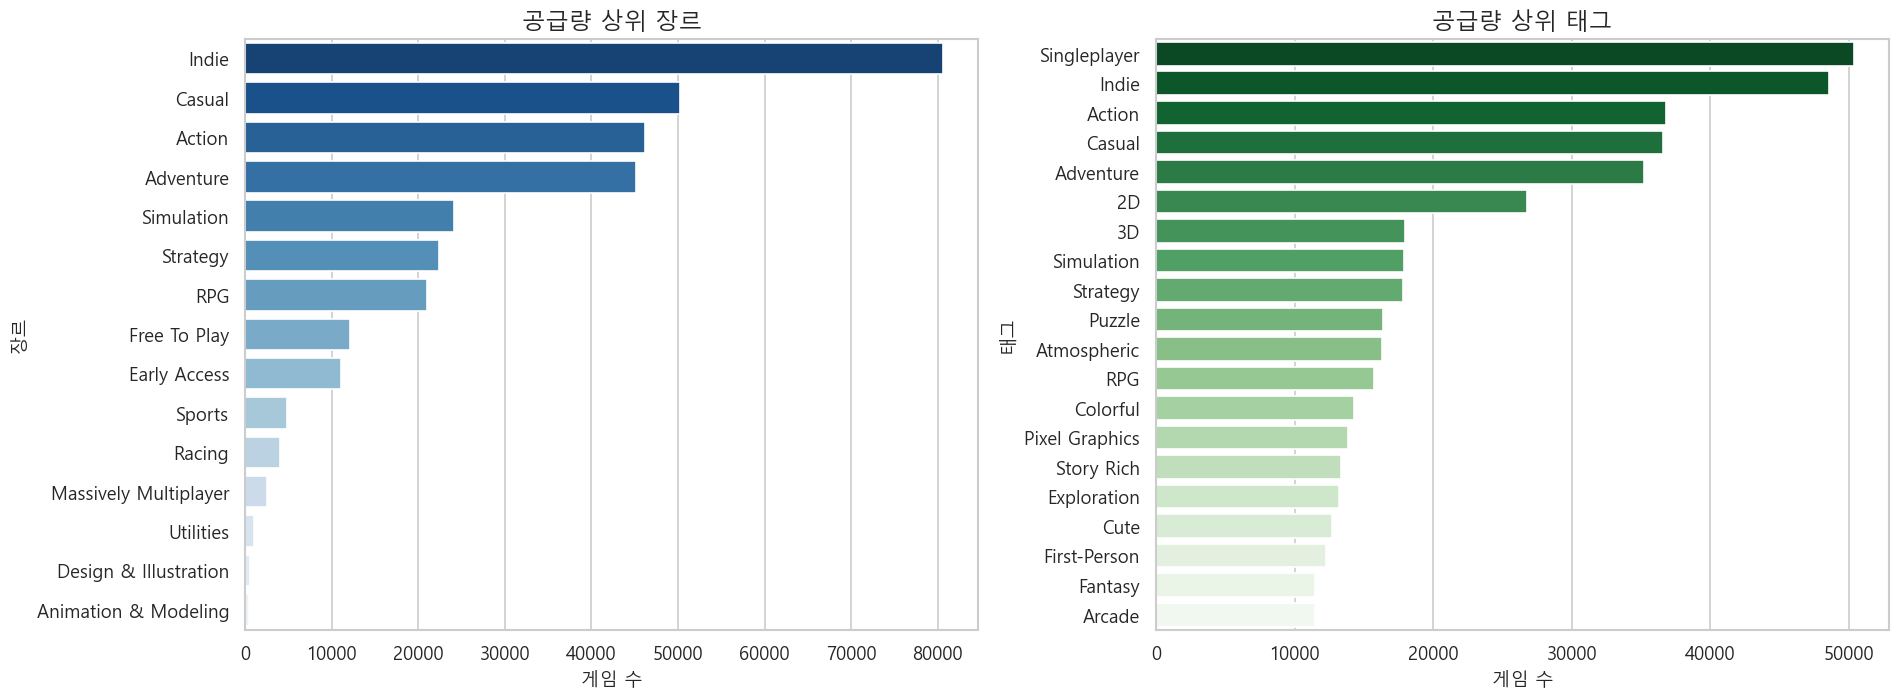

,market,game_count
0,Indie,80630
1,Casual,50210
2,Action,46220
3,Adventure,45141
4,Simulation,24114
5,Strategy,22400
6,RPG,20972
7,Free To Play,12172
8,Early Access,11091
9,Sports,4882


,market,game_count
0,Singleplayer,50350
1,Indie,48552
2,Action,36809
3,Casual,36564
4,Adventure,35196
5,2D,26792
6,3D,17996
7,Simulation,17893
8,Strategy,17848
9,Puzzle,16368


In [6]:
genre_supply = (
    all_genre_long.groupby("market")
    .agg(game_count=("AppID", "nunique"))
    .sort_values("game_count", ascending=False)
    .head(15)
    .reset_index()
)

tag_supply = (
    all_tag_long.groupby("market")
    .agg(game_count=("AppID", "nunique"))
    .sort_values("game_count", ascending=False)
    .head(20)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽 그래프: Steam 공급량 상위 장르
sns.barplot(data=genre_supply, y="market", x="game_count", ax=axes[0], palette="Blues_r")
axes[0].set_title("공급량 상위 장르")
axes[0].set_xlabel("게임 수")
axes[0].set_ylabel("장르")

# 오른쪽 그래프: 세부 태그 기준 공급 과밀 시장
sns.barplot(data=tag_supply, y="market", x="game_count", ax=axes[1], palette="Greens_r")
axes[1].set_title("공급량 상위 태그")
axes[1].set_xlabel("게임 수")
axes[1].set_ylabel("태그")

finish_plot(fig)

display(genre_supply)
display(tag_supply.head(10))


### 결론 1

Steam 시장은 장르·태그별 공급량 차이가 매우 큽니다.  
특히 `Action`(액션), `Adventure`(모험), `Indie`(인디), `Casual`(가볍게 즐기는 게임), `Simulation`(시뮬레이션), `Strategy`(전략)처럼 넓은 범주의 장르는 이미 많은 게임이 집중된 과밀 시장입니다.

그러나 공급이 많다는 사실만으로 해당 시장의 매력도가 낮다고 판단할 수는 없습니다.  
게임 수가 많더라도 유저 수요(이용자의 관심과 구매 가능성) 역시 큰 시장일 수 있기 때문입니다.

**다음 분석:** 공급량과 시장 매력도의 관계를 검토합니다.

## 가설 2: 공급이 많은 장르도 진입하기에 매력적인 시장일 수 있을까?

### 분석

이번 단계에서는 장르별 **공급량**과 **수요 강도**만 단순하게 비교합니다.  
핵심은 공급이 많다는 사실 자체가 아니라, 그 공급을 받아줄 만큼 일반적인 게임의 수요도 함께 큰지 확인하는 것입니다.

이 가설을 분석하기 위해 공급은 `전체 게임 수`, 수요 강도는 `중위 리뷰 수`로 보았습니다.  
전체 게임 수는 해당 장르에 이미 얼마나 많은 게임이 들어와 있는지를 보여주고, 중위 리뷰 수는 특정 대형 히트작이 아니라 **일반적인 게임이 어느 정도 관심을 받는지**를 보여주기 때문입니다.

그래프는 원래 숫자를 그대로 비교하기보다, 각 장르가 전체 장르 중 어느 정도 위치에 있는지 순위 백분위로 바꾸어 표시했습니다.

- x축: 공급량 순위 백분위(높을수록 게임 수가 많은 장르)
- y축: 수요 강도 순위 백분위(높을수록 중위 리뷰 수가 높은 장르)
- 색상: 시장 유형

기준선 50은 복잡한 계산값이 아니라 **전체 장르 중 상위 절반과 하위 절반을 나누는 기준**입니다.  
따라서 오른쪽은 공급이 많은 편, 왼쪽은 공급이 적은 편이고, 위쪽은 일반적인 게임의 수요가 높은 편, 아래쪽은 낮은 편으로 해석하면 됩니다.

| 위치 | 해석 |
|---|---|
| 오른쪽 위 | 공급도 많고 수요도 큰 대형 시장 |
| 오른쪽 아래 | 공급은 많은데 성과가 낮은 공급 과밀 시장 |
| 왼쪽 위 | 게임 수는 적지만 성과가 좋은 기회 시장 |
| 왼쪽 아래 | 공급도 수요도 낮은 니치 시장 |

이 그래프는 "공급이 많다 = 무조건 나쁜 시장"이 아니라는 점을 확인하기 위한 것입니다.


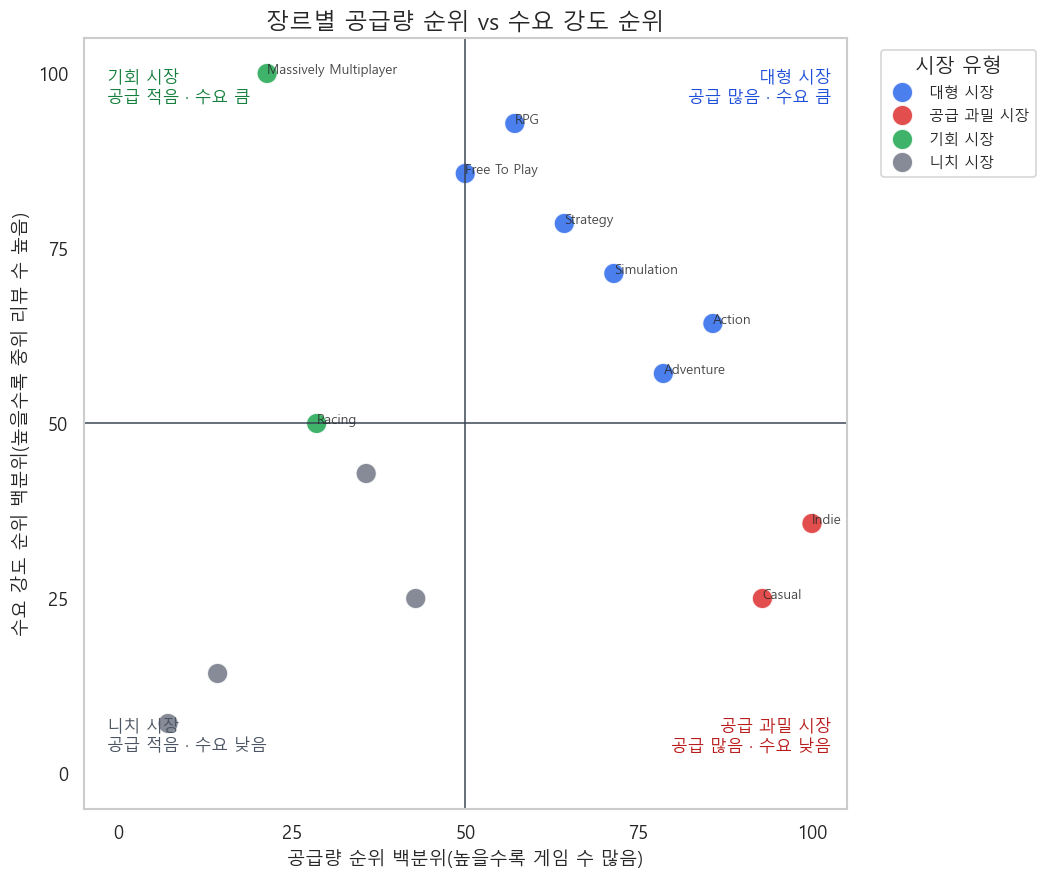

,market,market_type,all_game_count,median_reviews,supply_percentile,demand_percentile,median_owners,median_positive_ratio
15,Indie,공급 과밀 시장,80630,110.0,100.000000,35.714286,10000.0,0.819145
6,Casual,공급 과밀 시장,50210,96.0,92.857143,25.000000,10000.0,0.826923
21,Racing,기회 시장,4079,131.0,28.571429,50.000000,10000.0,0.782025
16,Massively Multiplayer,기회 시장,2527,280.5,21.428571,100.000000,35000.0,0.674118
9,Early Access,니치 시장,11091,96.0,42.857143,25.000000,10000.0,0.766423
26,Sports,니치 시장,4882,114.0,35.714286,42.857143,10000.0,0.782482
31,Violent,니치 시장,414,70.5,14.285714,14.285714,10000.0,0.618725
14,Gore,니치 시장,257,69.5,7.142857,7.142857,10000.0,0.590097
2,Action,대형 시장,46220,136.0,85.714286,64.285714,35000.0,0.800000
3,Adventure,대형 시장,45141,132.0,78.571429,57.142857,35000.0,0.817073


In [7]:
plot_df = genre_metrics.copy()
plot_df["supply_percentile"] = plot_df["all_game_count"].rank(pct=True) * 100
plot_df["demand_percentile"] = plot_df["median_reviews"].rank(pct=True) * 100
position_cutoff = 50

conditions = [
    (plot_df["supply_percentile"] >= position_cutoff) & (plot_df["demand_percentile"] >= position_cutoff),
    (plot_df["supply_percentile"] >= position_cutoff) & (plot_df["demand_percentile"] < position_cutoff),
    (plot_df["supply_percentile"] < position_cutoff) & (plot_df["demand_percentile"] >= position_cutoff),
    (plot_df["supply_percentile"] < position_cutoff) & (plot_df["demand_percentile"] < position_cutoff),
]
market_types = ["대형 시장", "공급 과밀 시장", "기회 시장", "니치 시장"]
plot_df["market_type"] = np.select(conditions, market_types, default="분류 제외")

market_palette = {
    "대형 시장": "#2563EB",
    "공급 과밀 시장": "#DC2626",
    "기회 시장": "#16A34A",
    "니치 시장": "#6B7280",
}

fig, ax = plt.subplots(figsize=(11.5, 7.5))
sns.scatterplot(
    data=plot_df,
    x="supply_percentile",
    y="demand_percentile",
    hue="market_type",
    hue_order=market_types,
    palette=market_palette,
    s=150,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)

ax.grid(False)
ax.axvline(position_cutoff, color="#374151", linestyle="-", linewidth=1.2, alpha=0.75)
ax.axhline(position_cutoff, color="#374151", linestyle="-", linewidth=1.2, alpha=0.75)
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title("장르별 공급량 순위 vs 수요 강도 순위")
ax.set_xlabel("공급량 순위 백분위(높을수록 게임 수 많음)")
ax.set_ylabel("수요 강도 순위 백분위(높을수록 중위 리뷰 수 높음)")

# 사분면별 해석 라벨
ax.text(0.98, 0.96, "대형 시장\n공급 많음 · 수요 큼", transform=ax.transAxes,
        ha="right", va="top", fontsize=10, color="#1D4ED8")
ax.text(0.98, 0.07, "공급 과밀 시장\n공급 많음 · 수요 낮음", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=10, color="#B91C1C")
ax.text(0.03, 0.96, "기회 시장\n공급 적음 · 수요 큼", transform=ax.transAxes,
        ha="left", va="top", fontsize=10, color="#15803D")
ax.text(0.03, 0.07, "니치 시장\n공급 적음 · 수요 낮음", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=10, color="#4B5563")

# 가독성 확보를 위한 주요 장르 라벨 표시
label_df = pd.concat([
    plot_df.nlargest(5, "supply_percentile"),
    plot_df.nlargest(5, "demand_percentile"),
    plot_df[plot_df["market_type"] == "기회 시장"].nlargest(4, "demand_percentile"),
    plot_df[plot_df["market_type"] == "공급 과밀 시장"].nlargest(4, "supply_percentile"),
]).drop_duplicates("market")
annotate_points(ax, label_df, "market", "supply_percentile", "demand_percentile", n=len(label_df))

ax.legend(
    bbox_to_anchor=(1.03, 1),
    loc="upper left",
    frameon=True,
    borderaxespad=0.8,
    title="시장 유형",
)
finish_plot(fig, right_margin=0.78)

plot_df[[
    "market", "market_type", "all_game_count", "median_reviews",
    "supply_percentile", "demand_percentile", "median_owners", "median_positive_ratio"
]].sort_values(["market_type", "supply_percentile"], ascending=[True, False])


### 결론 2

게임 수가 많은 장르라도, 수요가 함께 크면 반드시 나쁜 시장은 아닙니다.  
오른쪽 위의 대형 시장은 공급량도 상위 절반이고 중위 리뷰 수 역시 상위 절반이기 때문에, 경쟁은 강하더라도 시장 자체의 수요가 큰 영역으로 해석할 수 있습니다.

반대로 오른쪽 아래의 공급 과밀 시장은 게임 수는 많지만 중위 성과가 낮아, 일반적인 게임이 충분한 관심을 받기 어려운 시장일 가능성이 큽니다.  
왼쪽 위의 기회 시장은 공급은 상대적으로 적지만 중위 성과가 높아, 신작 기획 단계에서 우선 검토할 만한 후보가 됩니다.

다만 이 결과는 인과관계를 직접 증명하지는 않습니다.  
즉, "공급이 많은 장르라서 수요가 많아졌다"기보다는 **수요가 큰 장르에 개발사들의 공급이 많이 몰렸다**고 해석할 수도 있습니다. 따라서 가설 2의 핵심은 공급이 수요를 만든다는 주장이 아니라, 현재 Steam 시장에서 공급량과 수요 강도를 함께 보아야 시장 유형을 올바르게 구분할 수 있다는 점입니다.

**다음 분석:** 총수요와 게임당 수요의 차이를 검토합니다.


## 가설 3: 장르의 매력도는 총수요보다 게임당 수요로 판단해야 한다.

### 분석

총 리뷰 수(해당 장르에 속한 모든 게임의 리뷰 수 합계)가 큰 장르는 시장 전체 규모가 크다는 의미입니다.  
그러나 신작 관점에서는 시장 전체 규모보다 **평균적인 한 게임이 받는 관심도**가 더 중요한 판단 기준이라고 생각합니다.

아래 그래프는 왼쪽에 총 리뷰 수 상위 장르를, 오른쪽에 게임당 평균 리뷰 수 상위 장르를 제시합니다.


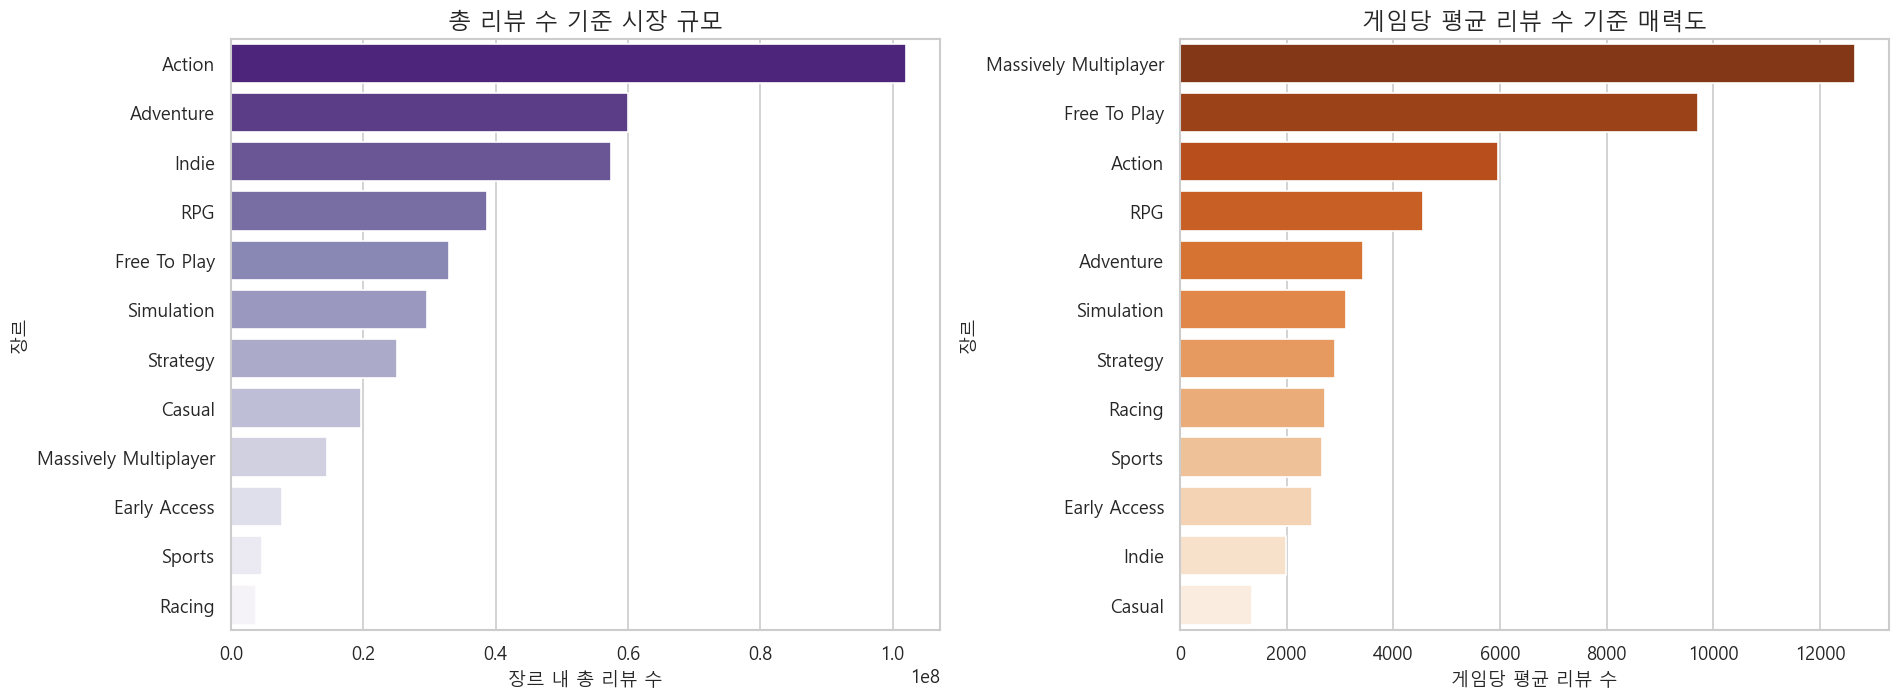

,market,all_game_count,total_reviews_sum,mean_reviews_per_game,median_reviews,mean_owners_per_game,median_owners
16,Massively Multiplayer,2527,14455202.0,12657.795096,280.5,1.063209e+06,35000.0
12,Free To Play,12172,32913216.0,9714.644628,165.0,6.643861e+05,35000.0
2,Action,46220,102004790.0,5965.192398,136.0,3.685140e+05,35000.0
20,RPG,20972,38739364.0,4547.407442,182.0,3.068259e+05,35000.0
3,Adventure,45141,60005615.0,3432.619129,132.0,2.346433e+05,35000.0
24,Simulation,24114,29640295.0,3105.647003,145.0,1.990051e+05,10000.0
27,Strategy,22400,25078617.0,2898.591886,147.0,2.194383e+05,35000.0
21,Racing,4079,3867458.0,2725.481325,131.0,1.640874e+05,10000.0
26,Sports,4882,4717285.0,2656.128941,114.0,2.128153e+05,10000.0
9,Early Access,11091,7755203.0,2472.171820,96.0,1.726650e+05,10000.0


In [8]:
total_demand_top = genre_metrics.sort_values("total_reviews_sum", ascending=False).head(12)
per_game_top = genre_metrics.sort_values("mean_reviews_per_game", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 총수요가 큰 장르: 큰 시장 규모와 높은 공급 가능성
sns.barplot(data=total_demand_top, y="market", x="total_reviews_sum", ax=axes[0], palette="Purples_r")
axes[0].set_title("총 리뷰 수 기준 시장 규모")
axes[0].set_xlabel("장르 내 총 리뷰 수")
axes[0].set_ylabel("장르")

# 게임당 수요가 큰 장르: 신규 게임 관점의 직접적 관심도 지표
sns.barplot(data=per_game_top, y="market", x="mean_reviews_per_game", ax=axes[1], palette="Oranges_r")
axes[1].set_title("게임당 평균 리뷰 수 기준 매력도")
axes[1].set_xlabel("게임당 평균 리뷰 수")
axes[1].set_ylabel("장르")

finish_plot(fig)

genre_metrics[[
    "market", "all_game_count", "total_reviews_sum", "mean_reviews_per_game",
    "median_reviews", "mean_owners_per_game", "median_owners"
]].sort_values("mean_reviews_per_game", ascending=False).head(15)


### 결론 3

총수요가 큰 장르와 게임당 수요가 큰 장르는 완전히 일치하지 않습니다.  
즉, 시장 전체가 커 보이더라도 실제로는 다수의 게임이 수요를 나누어 갖는 구조일 수 있습니다.

신규 진입 관점에서는 `총 리뷰 수`(시장 전체 관심도)보다 `게임당 평균 리뷰 수`, `중위 리뷰 수`, `게임당 owners 추정치`(게임당 보유자 수 추정값 =: 게임 당 구매 수요)가 더 직접적인 판단 기준입니다.

다만 게임당 수요가 높더라도 상위 소수 게임이 대부분의 관심을 가져가는 시장이라면 신규 진입 리스크가 큽니다.

**다음 분석:** 장르별 승자독식 구조를 검토합니다.


## 가설 4: 일부 장르는 승자독식 구조가 강해 신규 진입 리스크가 높은가?

### 분석

이번 단계에서는 장르별 성과 분산(게임 간 성과 차이)과 상위 집중도(성과가 상위 게임에 몰리는 정도)를 검토합니다.

- `Gini 계수`: 리뷰 수가 소수 게임에 얼마나 불균등하게 집중되어 있는지 나타내는 통계 지표입니다.
- `상위 1% 리뷰 점유율`: 장르 내 상위 1% 게임이 전체 리뷰에서 차지하는 비율입니다.
- `90분위수 / 중위값`: 일반적인 게임과 상위권 게임 사이의 격차를 보여주는 비율입니다.

이 시각화는 총수요가 크더라도 신규 게임이 진입하기 위험한 시장을 식별하기 위한 것입니다.


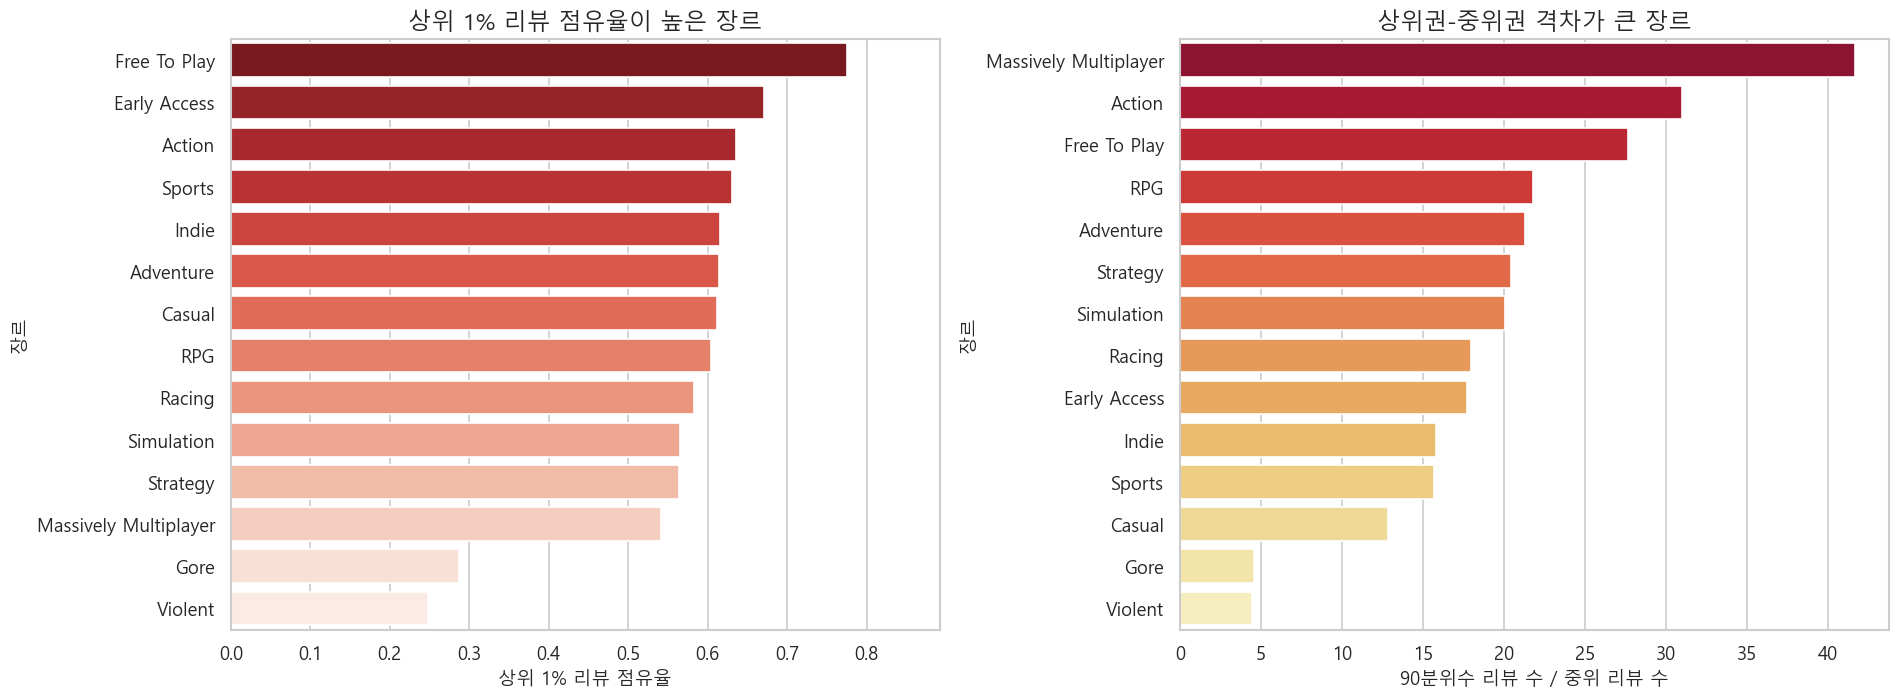

,market,all_game_count,median_reviews,p90_reviews,review_gini,top1_review_share,p90_to_median_ratio
12,Free To Play,12172,165.0,4563.4,0.964702,0.775455,27.656970
9,Early Access,11091,96.0,1698.4,0.937364,0.670301,17.691667
2,Action,46220,136.0,4217.0,0.947308,0.636191,31.007353
26,Sports,4882,114.0,1788.5,0.933560,0.630143,15.688596
15,Indie,80630,110.0,1741.7,0.919812,0.614873,15.833636
3,Adventure,45141,132.0,2808.0,0.933982,0.614013,21.272727
6,Casual,50210,96.0,1235.4,0.908308,0.611440,12.868750
20,RPG,20972,182.0,3971.6,0.930361,0.604618,21.821978
21,Racing,4079,131.0,2352.4,0.921919,0.582985,17.957252
24,Simulation,24114,145.0,2913.4,0.921235,0.564511,20.092414


In [9]:
concentration_top = genre_metrics.sort_values("top1_review_share", ascending=False).head(15)
gap_top = genre_metrics.sort_values("p90_to_median_ratio", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상위 1% 점유율: 소수 히트작 중심 시장 여부 판단 지표
sns.barplot(data=concentration_top, y="market", x="top1_review_share", ax=axes[0], palette="Reds_r")
axes[0].set_title("상위 1% 리뷰 점유율이 높은 장르")
axes[0].set_xlabel("상위 1% 리뷰 점유율")
axes[0].set_ylabel("장르")
axes[0].set_xlim(0, min(1, concentration_top["top1_review_share"].max() * 1.15))

# 90분위수/중위값 비율: 일반 게임과 상위권 게임의 성과 격차 지표
sns.barplot(data=gap_top, y="market", x="p90_to_median_ratio", ax=axes[1], palette="YlOrRd_r")
axes[1].set_title("상위권-중위권 격차가 큰 장르")
axes[1].set_xlabel("90분위수 리뷰 수 / 중위 리뷰 수")
axes[1].set_ylabel("장르")

finish_plot(fig)

genre_metrics[[
    "market", "all_game_count", "median_reviews", "p90_reviews",
    "review_gini", "top1_review_share", "p90_to_median_ratio"
]].sort_values("top1_review_share", ascending=False).head(15)


### 결론 4

총수요가 크더라도 상위 집중도가 높은 장르는 신규 진입 리스크가 큽니다.  
이러한 시장에서는 소수의 대형 히트작이 대부분의 관심을 확보하며, 일반적인 신작은 노출과 관심 확보가 어려울 가능성이 높습니다.

따라서 매력적인 시장은 단순히 수요가 큰 곳이 아니라, **수요가 존재하면서도 상위 집중도가 과도하게 높지 않은 곳**이어야 합니다.

**다음 분석:** 인디 게임의 상위권 진입 사례를 검토합니다.


## 가설 5: 인디 게임의 상위권 진입 가능성은 장르·태그별로 다른가?

### 분석

인디 게임(상대적으로 작은 규모의 개발팀이 제작한 게임)이 상위권에 진입한 시장은 소규모 개발팀에게 현실적인 진입 가능성이 있는 시장일 수 있습니다.  

여기서는 각 장르·태그 안에서 리뷰 수 상위 10% 게임을 추출하고, 그중 인디 게임 비중을 계산합니다.
이 시각화는 인디 게임이 실제로 상위권에 진입한 시장을 확인하기 위한 것입니다.


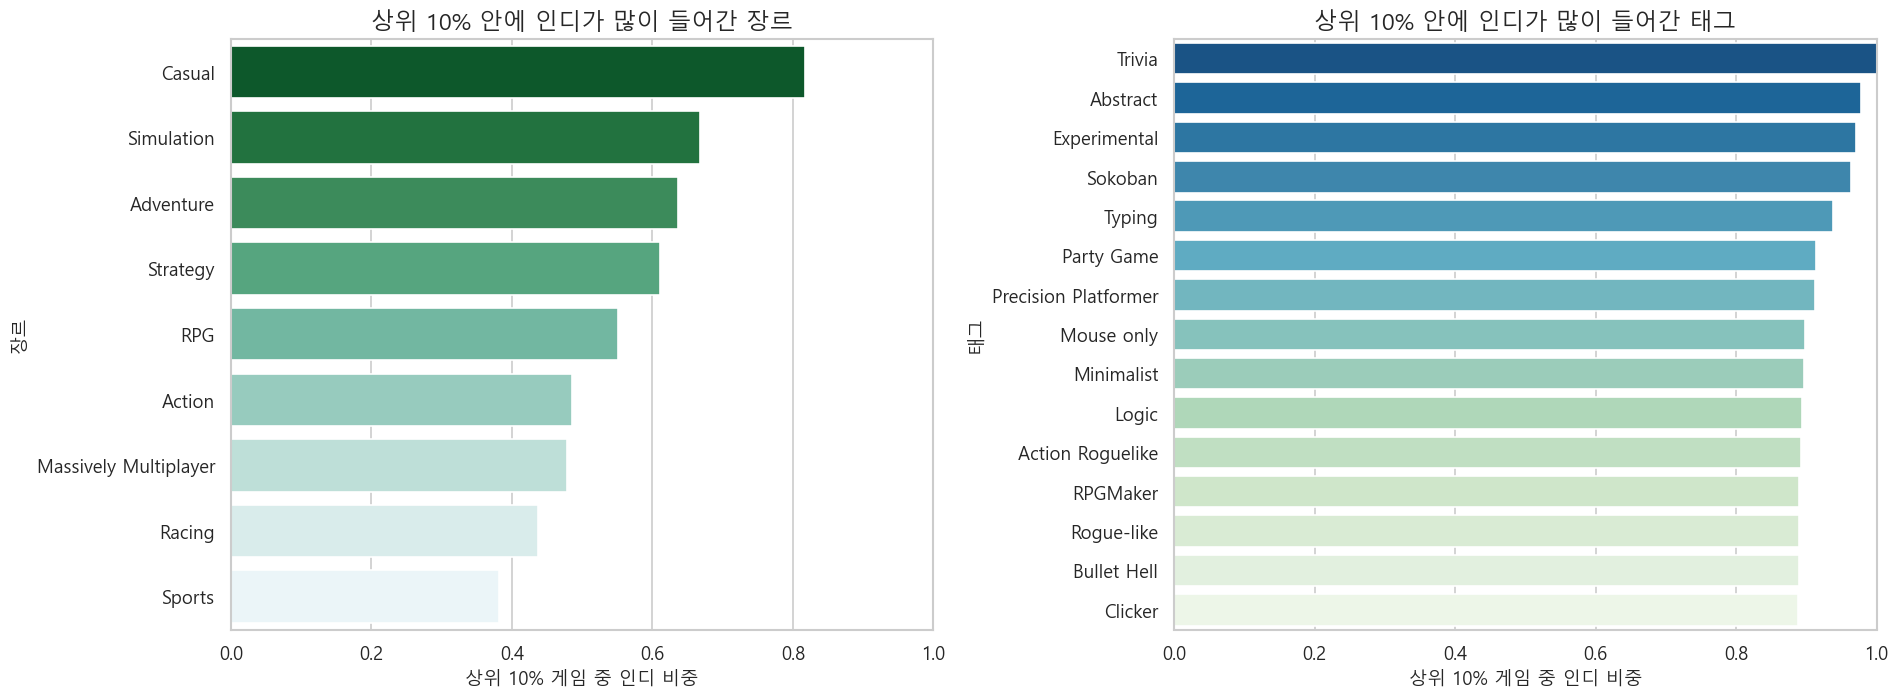

,market,all_game_count,top10_count,top10_indie_share,median_reviews,p90_reviews
6,Casual,50210,1456.0,0.817308,96.0,1235.4
24,Simulation,24114,955.0,0.668063,145.0,2913.4
3,Adventure,45141,1749.0,0.636364,132.0,2808.0
27,Strategy,22400,866.0,0.610855,147.0,3001.3
20,RPG,20972,852.0,0.551643,182.0,3971.6
2,Action,46220,1711.0,0.486265,136.0,4217.0
16,Massively Multiplayer,2527,115.0,0.478261,280.5,11691.8
21,Racing,4079,142.0,0.436620,131.0,2352.4
26,Sports,4882,178.0,0.382022,114.0,1788.5


,market,all_game_count,top10_count,top10_indie_share,median_reviews,p90_reviews
413,Trivia,330,14.0,1.000000,105.0,1078.8
16,Abstract,2177,91.0,0.978022,77.0,692.5
143,Experimental,1202,69.0,0.971014,111.0,1498.6
362,Sokoban,687,27.0,0.962963,54.0,493.0
420,Typing,404,16.0,0.937500,148.0,2255.0
284,Party Game,425,23.0,0.913043,181.5,4083.6
300,Precision Platformer,2322,80.0,0.912500,66.5,942.0
252,Mouse only,599,39.0,0.897436,127.5,2076.0
245,Minimalist,5618,213.0,0.896714,78.0,1012.6
221,Logic,4288,160.0,0.893750,67.0,732.1


In [10]:
genre_indie_entry = (
    actionable_genre_metrics[actionable_genre_metrics["top10_count"] >= 10]
    .sort_values("top10_indie_share", ascending=False)
    .head(15)
)

# 태그 자체가 Indie인 경우 정의상 제외
tag_indie_entry = (
    tag_metrics[(tag_metrics["top10_count"] >= 10) & (tag_metrics["market"] != "Indie")]
    .sort_values("top10_indie_share", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=genre_indie_entry, y="market", x="top10_indie_share", ax=axes[0], palette="BuGn_r")
axes[0].set_title("상위 10% 안에 인디가 많이 들어간 장르")
axes[0].set_xlabel("상위 10% 게임 중 인디 비중")
axes[0].set_ylabel("장르")
axes[0].set_xlim(0, 1)

sns.barplot(data=tag_indie_entry, y="market", x="top10_indie_share", ax=axes[1], palette="GnBu_r")
axes[1].set_title("상위 10% 안에 인디가 많이 들어간 태그")
axes[1].set_xlabel("상위 10% 게임 중 인디 비중")
axes[1].set_ylabel("태그")
axes[1].set_xlim(0, 1)

finish_plot(fig)

display(genre_indie_entry[["market", "all_game_count", "top10_count", "top10_indie_share", "median_reviews", "p90_reviews"]])
display(tag_indie_entry[["market", "all_game_count", "top10_count", "top10_indie_share", "median_reviews", "p90_reviews"]].head(10))


### 결론 5

인디 게임이 상위권에 진입한 장르·태그는 별도로 존재합니다.  
이러한 시장은 대형 퍼블리셔 중심 시장보다 소규모 팀에게 더 현실적인 후보가 될 수 있습니다.

**다음 분석:** 수요, 경쟁, 집중도, 인디 진입 가능성을 결합해 최종 기회 시장을 도출합니다.


## 가설 6: 기회 시장은 수요, 경쟁, 집중도, 인디 진입 가능성으로 정의할 수 있습니다

### 분석

최종 단계에서는 장르·태그별 Opportunity Score(기회 점수)를 산출합니다.  
점수는 아래 요소를 결합합니다.

- 게임당 중위 리뷰 수가 높은지 여부
- owners 중위값(게임 보유자 수 추정 범위의 중간값)이 높은지 여부
- 전체 게임 수가 과도하게 많지 않은지 여부
- Gini와 상위 1% 점유율이 낮아 승자독식 경향이 약한지 여부
- 상위권에 인디 게임이 실제로 진입했는지 여부

이 점수는 절대적인 정답이라기보다는, **신작 시장 후보를 좁히기 위한 의사결정 보조 지표**입니다.

또한 가중치가 하나의 값으로만 고정되면 결과가 달라질 수 있으므로, 마지막에는 여러 가중치 시나리오에서 반복적으로 상위권에 포함되는 시장을 확인합니다.


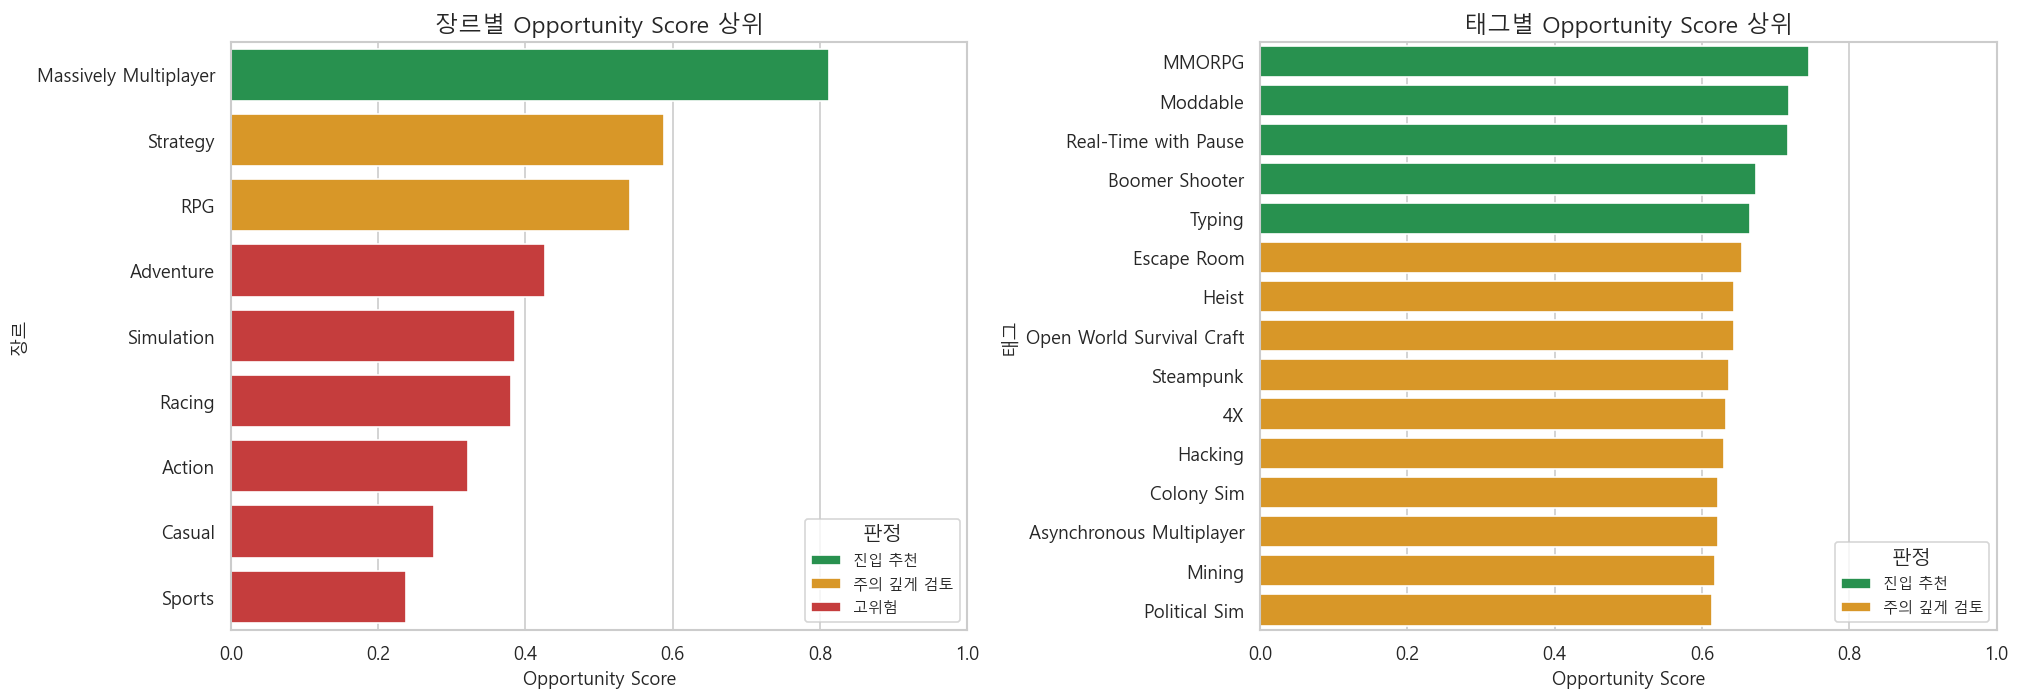

,market,market_label,opportunity_score,all_game_count,median_reviews,median_owners,top1_review_share,top10_indie_share
16,Massively Multiplayer,진입 추천,0.812,2527,280.5,35000.0,0.541,0.478
27,Strategy,주의 깊게 검토,0.587,22400,147.0,35000.0,0.564,0.611
20,RPG,주의 깊게 검토,0.542,20972,182.0,35000.0,0.605,0.552
3,Adventure,고위험,0.426,45141,132.0,35000.0,0.614,0.636
24,Simulation,고위험,0.386,24114,145.0,10000.0,0.565,0.668
21,Racing,고위험,0.380,4079,131.0,10000.0,0.583,0.437
2,Action,고위험,0.322,46220,136.0,35000.0,0.636,0.486
6,Casual,고위험,0.276,50210,96.0,10000.0,0.611,0.817
26,Sports,고위험,0.237,4882,114.0,10000.0,0.630,0.382


,market,market_label,opportunity_score,all_game_count,median_reviews,median_owners,top1_review_share,top10_indie_share
226,MMORPG,진입 추천,0.745,454,730.0,150000.0,0.333,0.278
248,Moddable,진입 추천,0.718,959,1241.0,150000.0,0.579,0.333
317,Real-Time with Pause,진입 추천,0.716,316,538.0,150000.0,0.338,0.154
57,Boomer Shooter,진입 추천,0.673,378,398.0,35000.0,0.386,0.667
420,Typing,진입 추천,0.665,404,148.0,35000.0,0.243,0.938
141,Escape Room,주의 깊게 검토,0.654,454,221.0,35000.0,0.288,0.857
185,Heist,주의 깊게 검토,0.643,269,523.5,35000.0,0.354,0.294
278,Open World Survival Craft,주의 깊게 검토,0.643,562,511.0,35000.0,0.417,0.762
375,Steampunk,주의 깊게 검토,0.637,516,229.0,75000.0,0.325,0.528
12,4X,주의 깊게 검토,0.633,440,491.5,75000.0,0.444,0.212


In [11]:
def add_opportunity_score(metrics):
    m = metrics.copy()
    m["review_demand_score"] = safe_minmax(np.log1p(m["median_reviews"]))
    m["owner_demand_score"] = safe_minmax(np.log1p(m["median_owners"]))
    m["competition_score"] = safe_minmax(np.log1p(m["all_game_count"]), invert=True)
    m["concentration_score"] = (
        0.5 * safe_minmax(m["review_gini"], invert=True)
        + 0.5 * safe_minmax(m["top1_review_share"], invert=True)
    )
    m["indie_entry_score"] = safe_minmax(m["top10_indie_share"].fillna(0))

    m["opportunity_score"] = (
        0.25 * m["review_demand_score"]
        + 0.20 * m["owner_demand_score"]
        + 0.20 * m["competition_score"]
        + 0.20 * m["concentration_score"]
        + 0.15 * m["indie_entry_score"]
    )
    m["market_label"] = np.select(
        [
            m["opportunity_score"] >= 0.66,
            m["opportunity_score"] >= 0.50,
        ],
        ["진입 추천", "주의 깊게 검토"],
        default="고위험",
    )
    return m.sort_values("opportunity_score", ascending=False)


genre_opportunity = add_opportunity_score(actionable_genre_metrics)
NON_ACTIONABLE_TAGS = {
    "Indie", "Free to Play", "Early Access", "Singleplayer", "Steam Achievements",
    "Cult Classic", "Classic", "Remake", "Remaster", "Sequel",
    "Great Soundtrack", "Masterpiece", "Touch-Friendly", "Illuminati",
    "Lara Croft", "Warhammer 40K", "Games Workshop"
}
tag_opportunity = add_opportunity_score(tag_metrics[~tag_metrics["market"].isin(NON_ACTIONABLE_TAGS)].copy())

top_genre_opportunity = genre_opportunity.head(15)
top_tag_opportunity = tag_opportunity.head(15)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(
    data=top_genre_opportunity,
    y="market",
    x="opportunity_score",
    hue="market_label",
    dodge=False,
    ax=axes[0],
    palette={"진입 추천": "#16A34A", "주의 깊게 검토": "#F59E0B", "고위험": "#DC2626"},
)
axes[0].set_title("장르별 Opportunity Score 상위")
axes[0].set_xlabel("Opportunity Score")
axes[0].set_ylabel("장르")
axes[0].set_xlim(0, 1)
axes[0].legend(title="판정", loc="lower right")

sns.barplot(
    data=top_tag_opportunity,
    y="market",
    x="opportunity_score",
    hue="market_label",
    dodge=False,
    ax=axes[1],
    palette={"진입 추천": "#16A34A", "주의 깊게 검토": "#F59E0B", "고위험": "#DC2626"},
)
axes[1].set_title("태그별 Opportunity Score 상위")
axes[1].set_xlabel("Opportunity Score")
axes[1].set_ylabel("태그")
axes[1].set_xlim(0, 1)
axes[1].legend(title="판정", loc="lower right")

finish_plot(fig)

display(top_genre_opportunity[[
    "market", "market_label", "opportunity_score", "all_game_count",
    "median_reviews", "median_owners", "top1_review_share",
    "top10_indie_share"
]].round(3))

display(top_tag_opportunity[[
    "market", "market_label", "opportunity_score", "all_game_count",
    "median_reviews", "median_owners", "top1_review_share",
    "top10_indie_share"
]].round(3))


### 가중치 민감도 분석

Opportunity Score(기회 시장 점수)는 여러 요소를 결합한 점수이기 때문에, 가중치 설정에 따라 순위가 달라질 수 있습니다.  
따라서 단일 점수만 확인하지 않고, 가중치를 다르게 둔 여러 시나리오에서도 반복적으로 상위권에 남는 시장을 확인합니다.

가중치는 실제 의사결정에서 자주 달라질 수 있는 판단 관점을 반영해 설정했습니다.

- `균형형`: 기본 기준입니다. 수요, 경쟁, 집중도, 인디 진입 가능성을 비교적 고르게 반영합니다.
- `수요 우선형`: 시장 크기를 가장 중요하게 보는 경우입니다. 리뷰 수요와 owners 규모에 더 큰 비중을 둡니다.
- `안전 진입형`: 경쟁이 너무 많거나 승자독식이 강한 시장을 피하려는 경우입니다. 경쟁 과밀도와 집중도 위험에 더 큰 비중을 둡니다.
- `인디 친화형`: 소규모 팀의 현실성을 더 중요하게 보는 경우입니다. 상위권에 인디 게임이 실제로 진입한 사례에 더 큰 비중을 둡니다.

각 시나리오의 가중치 합은 1이 되도록 설정했습니다.  

이 분석의 목적은 특정 가중치 하나가 정답이라고 주장하는 것이 아니라, **관점을 바꿔도 계속 상위권에 남는 후보가 더 안정적인 기회 시장인지** 확인하는 것입니다.


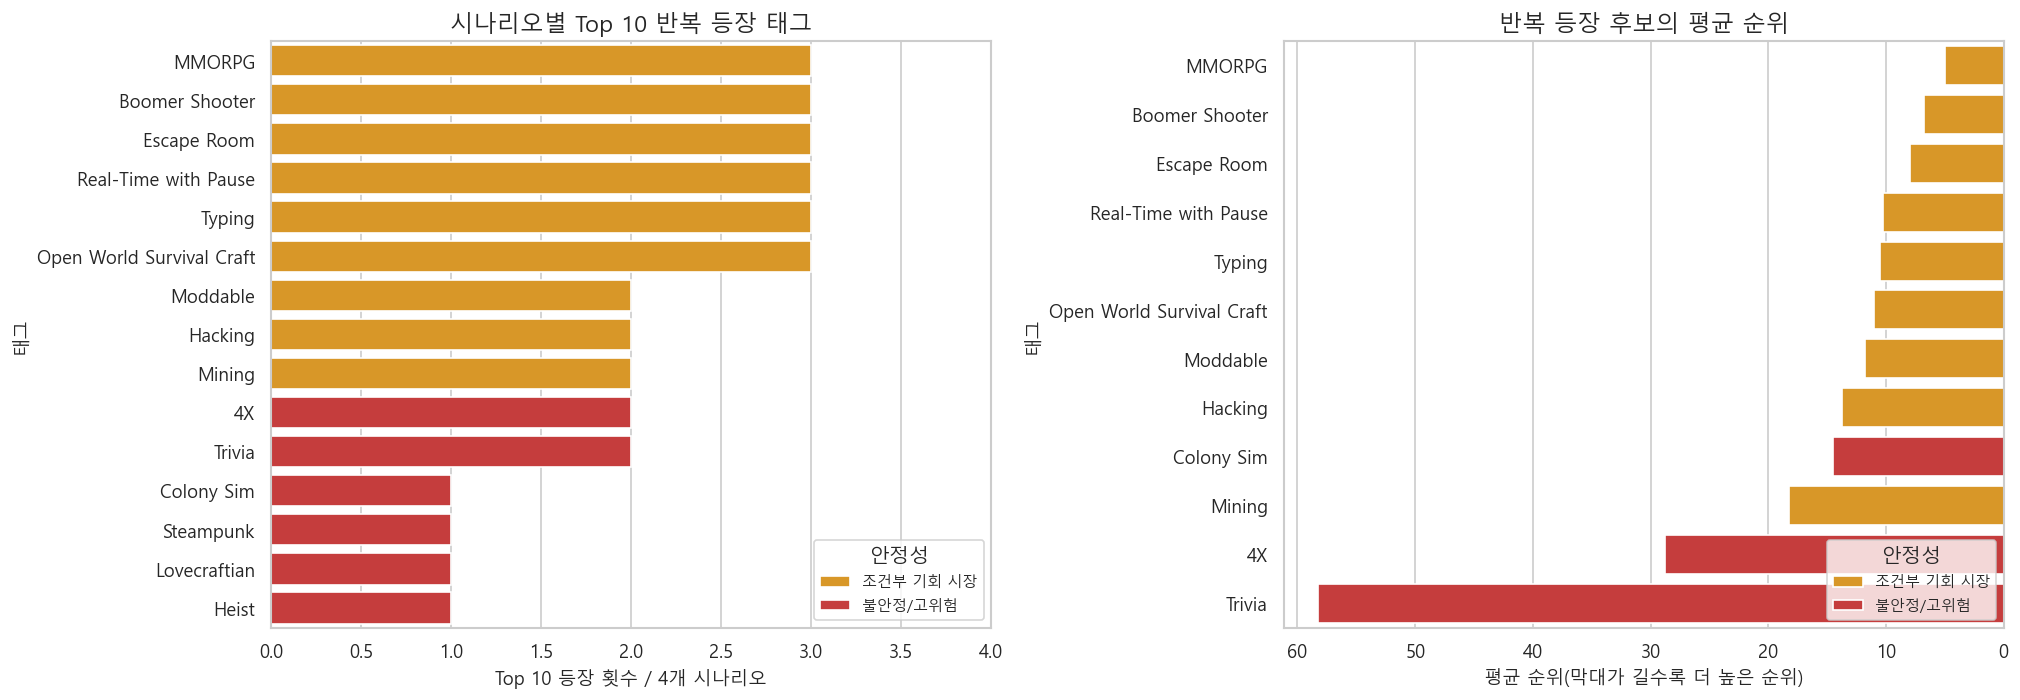

,market,안정성라벨,top10_등장횟수,평균순위,최악순위,순위표준편차,균형형_rank,수요 우선형_rank,안전 진입형_rank,인디 친화형_rank
16,Massively Multiplayer,안정적 기회 시장,4,1.00,1.0,0.00,1.0,1.0,1.0,1.0
27,Strategy,안정적 기회 시장,4,2.25,3.0,0.50,2.0,3.0,2.0,2.0
20,RPG,안정적 기회 시장,4,3.00,4.0,0.82,3.0,2.0,4.0,3.0
3,Adventure,조건부 기회 시장,3,4.75,7.0,1.50,4.0,4.0,7.0,4.0
24,Simulation,조건부 기회 시장,3,5.25,6.0,0.50,5.0,6.0,5.0,5.0
21,Racing,불안정/고위험,1,5.75,7.0,1.89,6.0,7.0,3.0,7.0
2,Action,불안정/고위험,1,7.25,9.0,1.71,7.0,5.0,9.0,8.0
6,Casual,불안정/고위험,0,7.00,8.0,1.15,8.0,8.0,6.0,6.0
26,Sports,불안정/고위험,0,8.75,9.0,0.50,9.0,9.0,8.0,9.0


,market,안정성라벨,top10_등장횟수,평균순위,최악순위,순위표준편차,균형형_rank,수요 우선형_rank,안전 진입형_rank,인디 친화형_rank
226,MMORPG,조건부 기회 시장,3,5.00,11.0,4.55,1.0,2.0,6.0,11.0
57,Boomer Shooter,조건부 기회 시장,3,6.75,13.0,4.27,4.0,13.0,4.0,6.0
141,Escape Room,조건부 기회 시장,3,8.00,21.0,8.83,6.0,21.0,3.0,2.0
317,Real-Time with Pause,조건부 기회 시장,3,10.25,28.0,11.98,3.0,3.0,7.0,28.0
420,Typing,조건부 기회 시장,3,10.50,35.0,16.44,5.0,35.0,1.0,1.0
278,Open World Survival Craft,조건부 기회 시장,3,11.00,22.0,7.53,8.0,9.0,22.0,5.0
248,Moddable,조건부 기회 시장,2,11.75,31.0,13.94,2.0,1.0,31.0,13.0
182,Hacking,조건부 기회 시장,2,13.75,24.0,6.85,11.0,24.0,10.0,10.0
246,Mining,조건부 기회 시장,2,18.25,46.0,18.95,14.0,46.0,9.0,4.0
12,4X,불안정/고위험,2,28.75,68.0,28.67,10.0,5.0,32.0,68.0


In [12]:
SCENARIO_WEIGHTS = {
    "균형형": {
        "review_demand_score": 0.25,
        "owner_demand_score": 0.20,
        "competition_score": 0.20,
        "concentration_score": 0.20,
        "indie_entry_score": 0.15,
    },
    "수요 우선형": {
        "review_demand_score": 0.40,
        "owner_demand_score": 0.30,
        "competition_score": 0.10,
        "concentration_score": 0.10,
        "indie_entry_score": 0.10,
    },
    "안전 진입형": {
        "review_demand_score": 0.15,
        "owner_demand_score": 0.10,
        "competition_score": 0.30,
        "concentration_score": 0.30,
        "indie_entry_score": 0.15,
    },
    "인디 친화형": {
        "review_demand_score": 0.20,
        "owner_demand_score": 0.15,
        "competition_score": 0.15,
        "concentration_score": 0.15,
        "indie_entry_score": 0.35,
    },
}


def scenario_ranking(base_df, scenario_weights):
    ranked = base_df.copy()
    for scenario, weights in scenario_weights.items():
        score_col = f"{scenario}_score"
        rank_col = f"{scenario}_rank"
        ranked[score_col] = sum(ranked[col] * weight for col, weight in weights.items())
        ranked[rank_col] = ranked[score_col].rank(ascending=False, method="min")
    return ranked


def stability_table(ranked, scenario_weights, top_n=10):
    rank_cols = [f"{scenario}_rank" for scenario in scenario_weights]
    score_cols = [f"{scenario}_score" for scenario in scenario_weights]

    stable = ranked[["market", "market_label", "opportunity_score", *rank_cols, *score_cols]].copy()
    stable["top10_등장횟수"] = (stable[rank_cols] <= top_n).sum(axis=1)
    stable["평균순위"] = stable[rank_cols].mean(axis=1)
    stable["최악순위"] = stable[rank_cols].max(axis=1)
    stable["순위표준편차"] = stable[rank_cols].std(axis=1)
    stable["안정성라벨"] = np.select(
        [
            (stable["top10_등장횟수"] >= len(scenario_weights)) & (stable["평균순위"] <= 10),
            (stable["top10_등장횟수"] >= 2) & (stable["평균순위"] <= 20),
        ],
        ["안정적 기회 시장", "조건부 기회 시장"],
        default="불안정/고위험",
    )
    return stable.sort_values(["top10_등장횟수", "평균순위", "순위표준편차"], ascending=[False, True, True])


genre_scenario_ranked = scenario_ranking(genre_opportunity, SCENARIO_WEIGHTS)
tag_scenario_ranked = scenario_ranking(tag_opportunity, SCENARIO_WEIGHTS)

genre_stability = stability_table(genre_scenario_ranked, SCENARIO_WEIGHTS, top_n=5)
tag_stability = stability_table(tag_scenario_ranked, SCENARIO_WEIGHTS, top_n=10)

scenario_rank_cols = [f"{scenario}_rank" for scenario in SCENARIO_WEIGHTS]
scenario_score_cols = [f"{scenario}_score" for scenario in SCENARIO_WEIGHTS]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# 왼쪽: 관점이 달라져도 Top 10에 반복적으로 남는지 확인
tag_stability_top = tag_stability.head(15).copy()
sns.barplot(
    data=tag_stability_top,
    y="market",
    x="top10_등장횟수",
    hue="안정성라벨",
    dodge=False,
    ax=axes[0],
    palette={"안정적 기회 시장": "#16A34A", "조건부 기회 시장": "#F59E0B", "불안정/고위험": "#DC2626"},
)
axes[0].set_title("시나리오별 Top 10 반복 등장 태그")
axes[0].set_xlabel(f"Top 10 등장 횟수 / {len(SCENARIO_WEIGHTS)}개 시나리오")
axes[0].set_ylabel("태그")
axes[0].set_xlim(0, len(SCENARIO_WEIGHTS))
axes[0].legend(title="안정성", loc="lower right")

# 오른쪽: 반복 등장 후보 중 평균 순위가 좋은 태그를 직접 비교
avg_rank_top = tag_stability.head(12).sort_values("평균순위", ascending=True)
sns.barplot(
    data=avg_rank_top,
    y="market",
    x="평균순위",
    hue="안정성라벨",
    dodge=False,
    ax=axes[1],
    palette={"안정적 기회 시장": "#16A34A", "조건부 기회 시장": "#F59E0B", "불안정/고위험": "#DC2626"},
)
axes[1].invert_xaxis()
axes[1].set_title("반복 등장 후보의 평균 순위")
axes[1].set_xlabel("평균 순위(막대가 길수록 더 높은 순위)")
axes[1].set_ylabel("태그")
axes[1].legend(title="안정성", loc="lower right")

finish_plot(fig)

display(genre_stability[[
    "market", "안정성라벨", "top10_등장횟수", "평균순위", "최악순위", "순위표준편차",
    *scenario_rank_cols
]].head(12).round(2))

display(tag_stability[[
    "market", "안정성라벨", "top10_등장횟수", "평균순위", "최악순위", "순위표준편차",
    *scenario_rank_cols
]].head(15).round(2))


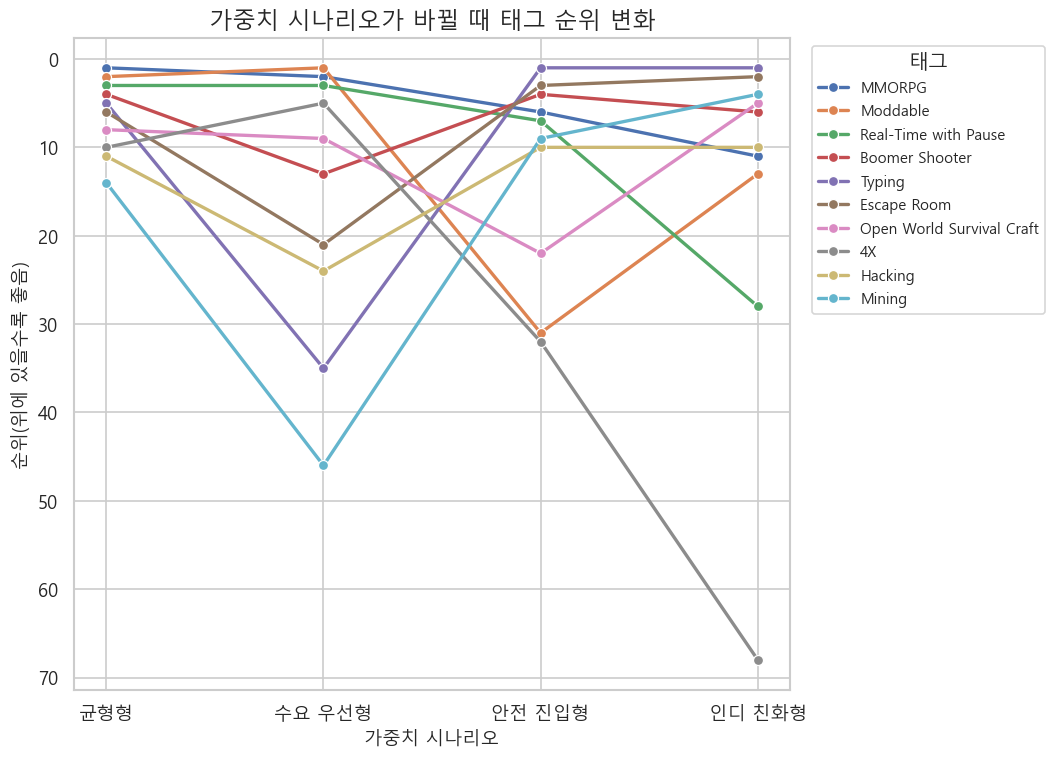

In [13]:
rank_change_df = (
    tag_stability.head(10)[["market", *scenario_rank_cols]]
    .melt(id_vars="market", var_name="scenario", value_name="rank")
)
rank_change_df["scenario"] = rank_change_df["scenario"].str.replace("_rank", "", regex=False)
rank_change_df["scenario"] = pd.Categorical(
    rank_change_df["scenario"],
    categories=list(SCENARIO_WEIGHTS.keys()),
    ordered=True,
)
rank_change_df = rank_change_df.sort_values(["scenario", "rank"])

plt.figure(figsize=(11, 6.5))
sns.lineplot(
    data=rank_change_df,
    x="scenario",
    y="rank",
    hue="market",
    marker="o",
    linewidth=2,
)
plt.gca().invert_yaxis()
plt.title("가중치 시나리오가 바뀔 때 태그 순위 변화")
plt.xlabel("가중치 시나리오")
plt.ylabel("순위(위에 있을수록 좋음)")
plt.legend(title="태그", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


### 결론 6

기회 시장은 단순히 수요가 큰 시장이 아닙니다.  
신규 진입 관점에서는 `수요`, `경쟁 과밀도`, `승자독식 위험`, `인디 진입 사례`를 함께 검토해야 합니다.

또한 Opportunity Score(기회 시장 점수)는 가중치에 따라 순위가 달라질 수 있으므로, 단일 점수만으로 결론을 내리는 것은 적절하지 않습니다.  

여러 가중치 시나리오에서 반복적으로 상위권에 남는 시장을 `안정적 기회 시장`으로 해석하는 것이 타당합니다.

최종 결과는 특정 장르 제작을 직접 지시하는 결론이 아니라, **신작 기획 단계에서 우선 검토할 시장 후보를 좁히는 도구**로 해석해야 합니다.

또한 본 데이터에는 개발비, 팀 규모, 서버 운영 난이도, 마케팅 비용이 포함되어 있지 않습니다. 예를 들어 `Massively Multiplayer`(대규모 다중 접속 게임)처럼 점수가 높게 산출되는 장르라도 실제 개발 난이도는 매우 높을 수 있으므로, 최종 의사결정에서는 별도의 리스크 검토가 필요합니다.
